# KDD Part 1 - Joelle , Farah

# 1. Importing libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix

# 2. Loading and Exploring

In [2]:
df = pd.read_csv(r'titanic.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [6]:
# of records & features
print("# of records : ",df.shape[0])
print("# of features : ", df.shape[1])

# of records :  891
# of features :  12


# 3. Basic Data Cleaning

In [7]:
# Check datatypes and missing values
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### --------- Fill Null values ---------

In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

### --------- Remove duplications ---------

In [9]:
df.drop_duplicates(inplace=True)

### --------- Prepare Target Column ---------

In [10]:
# the taget is "survived column"
df["y"] = df["Survived"]
df.drop(columns="Survived",inplace=True)

### --------- drop useless columns ---------

In [11]:
df.drop(columns="PassengerId",inplace=True)
df.drop(columns="Cabin",inplace=True)
df.drop(columns="Ticket",inplace=True)

### --------- features extraction & features engineering ---------


In [12]:
df["Title"] = df["Name"].str.split(",").str[1].str.split(".").str[0].str.strip()
df.drop(columns="Name",inplace=True)

df["familySize"] = df["SibSp"] + df["Parch"]

### Checking for Null values

In [13]:
print(df.isnull().sum())

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
y             0
Title         0
familySize    0
dtype: int64


# 4. Exploring & Visualizing Data

Correlation Matrix

In [14]:
corr = df.corr(numeric_only=True)
corr['y'].sort_values(ascending=False)
abs(corr['y']).sort_values(ascending=False)

y             1.000000
Pclass        0.338481
Fare          0.257307
Parch         0.081629
Age           0.064910
SibSp         0.035322
familySize    0.016639
Name: y, dtype: float64

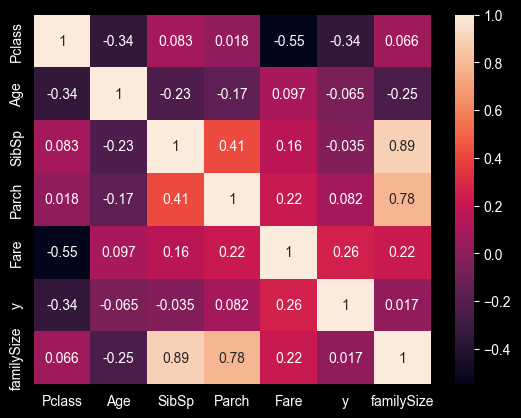

In [15]:
sns.heatmap(corr, annot=True)
plt.show()

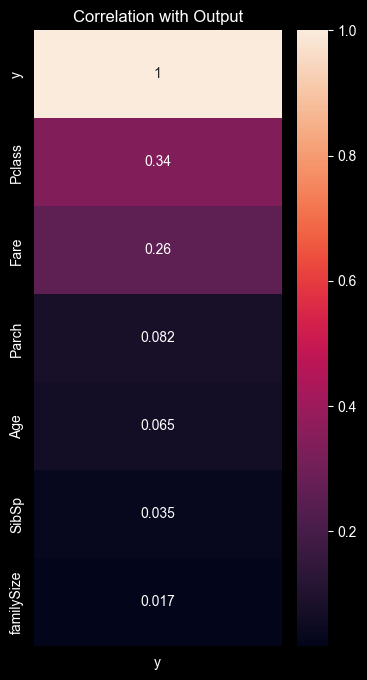

In [16]:

corr_matrix = df.select_dtypes(include=['number']).corr()
output_corr = corr_matrix[['y']].abs().sort_values(by='y', ascending=False)

plt.figure(figsize=(4, 8))
sns.heatmap(output_corr, annot=True)
plt.title('Correlation with Output')
plt.show()

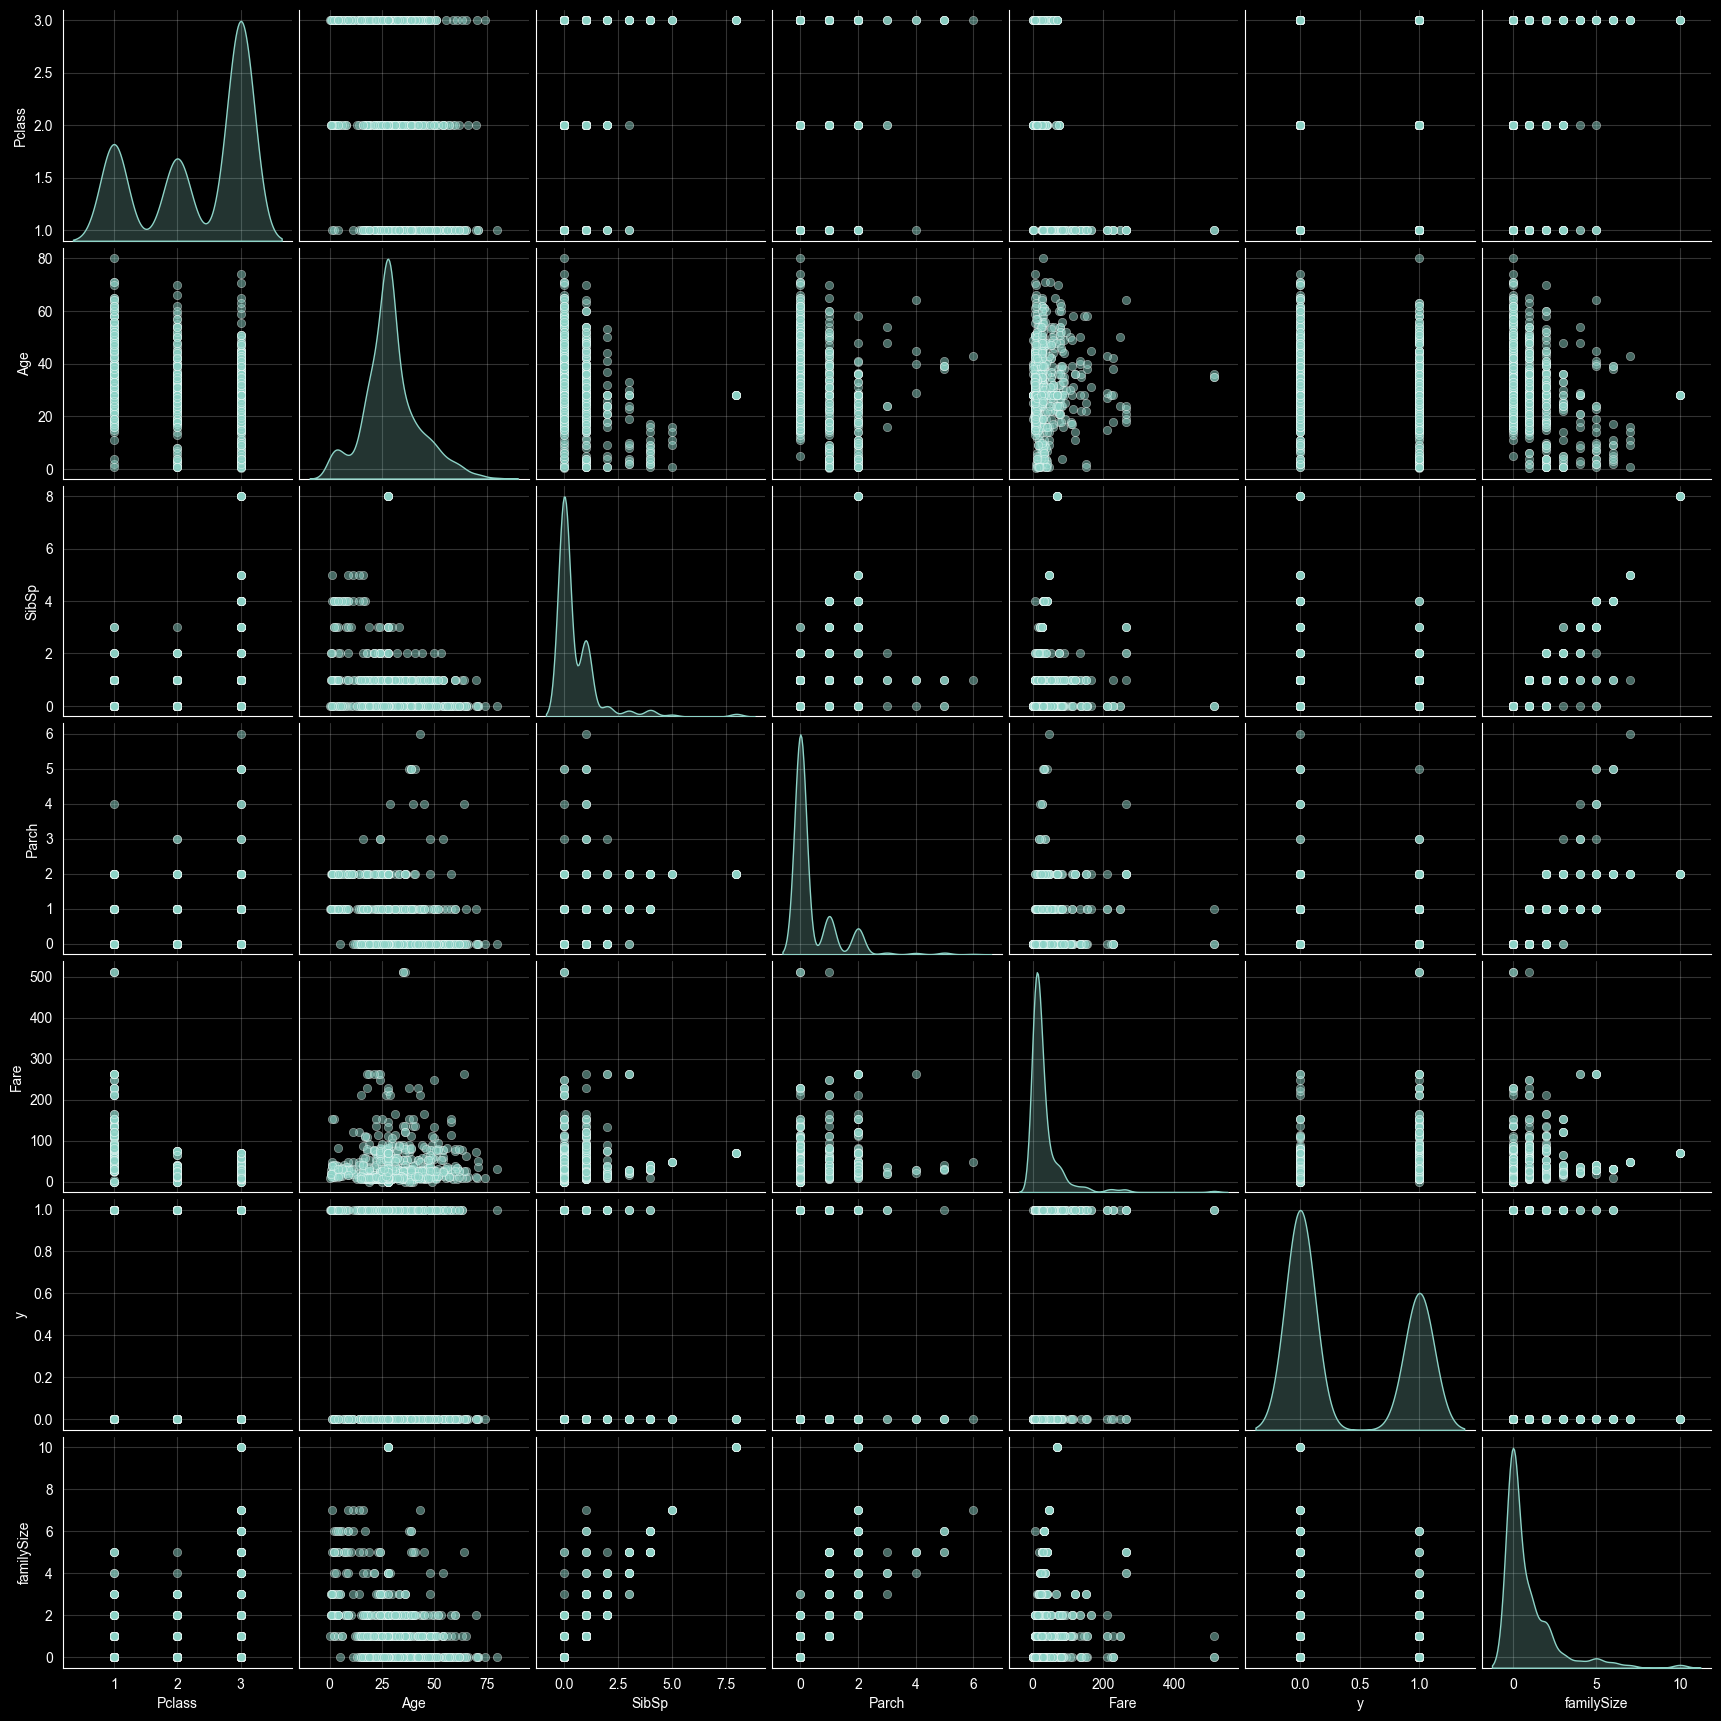

In [17]:
plt.style.use("dark_background")
g = sns.pairplot(
    data=df,
    diag_kind="kde",
    plot_kws={"alpha": 0.5}
)
# Change grid transparency
for ax in g.axes.flatten():
    if ax is not None:
        ax.grid(True, alpha=0.2)  # Change alpha here
plt.show()

### Notice that the Target in slightly imbalanced

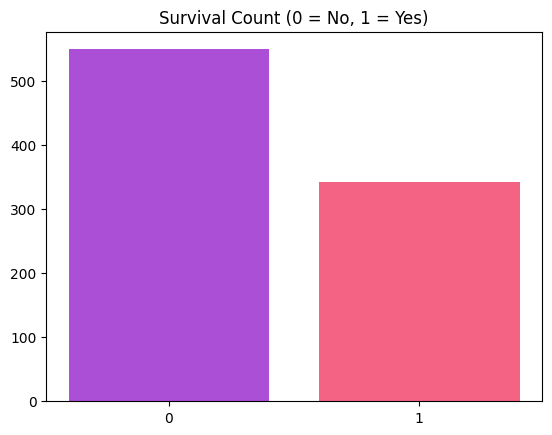

In [18]:
# Visualize Survival (Target)
plt.style.use('default')
survival_counts = df['y'].value_counts()
plt.bar(survival_counts.index.astype(str), survival_counts.values,color=["#ab4fd7","#f46383"])
plt.title('Survival Count (0 = No, 1 = Yes)')
plt.show()

##                                               62% ` NO ` , 38% ` YES `

In [172]:
df['y'].value_counts(normalize=True)

y
0    0.616162
1    0.383838
Name: proportion, dtype: float64

### Finding Outliers in "Age" column using IQR Algorithm

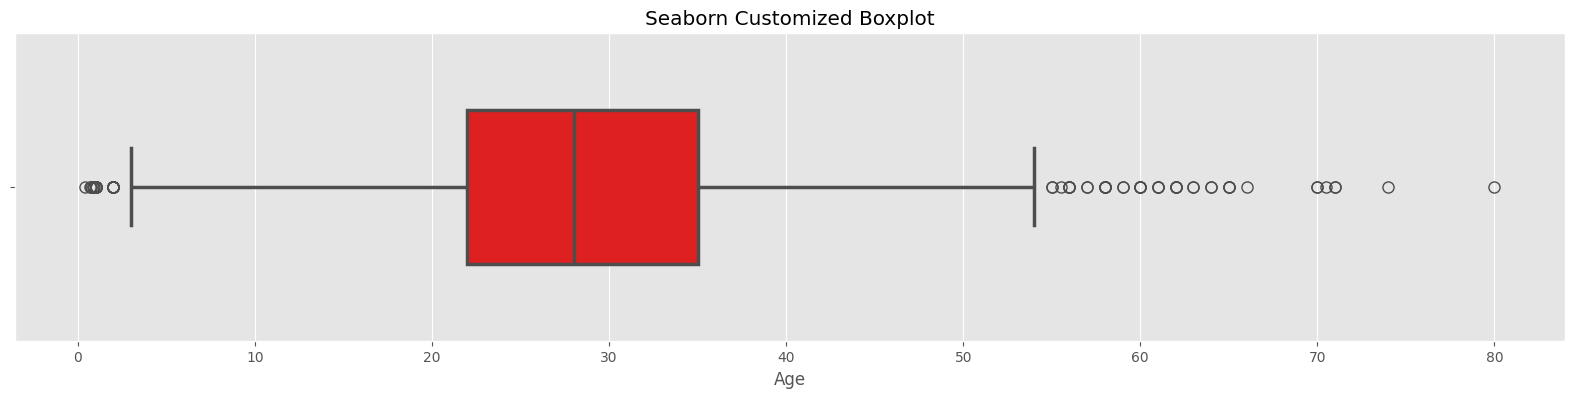

In [19]:
# Outlier Detection for 'Age'
plt.style.use('ggplot')
plt.figure(figsize=(20, 4))
sns.boxplot(
    x=df['Age'],
    color='red',       # The fill color of the box
    linewidth=2.5,         # Thickness of all lines (box, whiskers, etc.)
    fliersize=8,           # Size of the outlier points
    width=0.5              # Thickness/height of the box itself
)
plt.title('Seaborn Customized Boxplot')
plt.show()

In [173]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(f"lower limit: {lower_limit}, upper limit: {upper_limit}")

lower limit: 2.5, upper limit: 54.5


In [174]:
# remove the rows in the range
df = df[(df['Age'] >= lower_limit) & (df['Age'] <= upper_limit)]

In [175]:
df.shape

(825, 10)

### "Age" Boxplot Before Vs After Removing Outliers

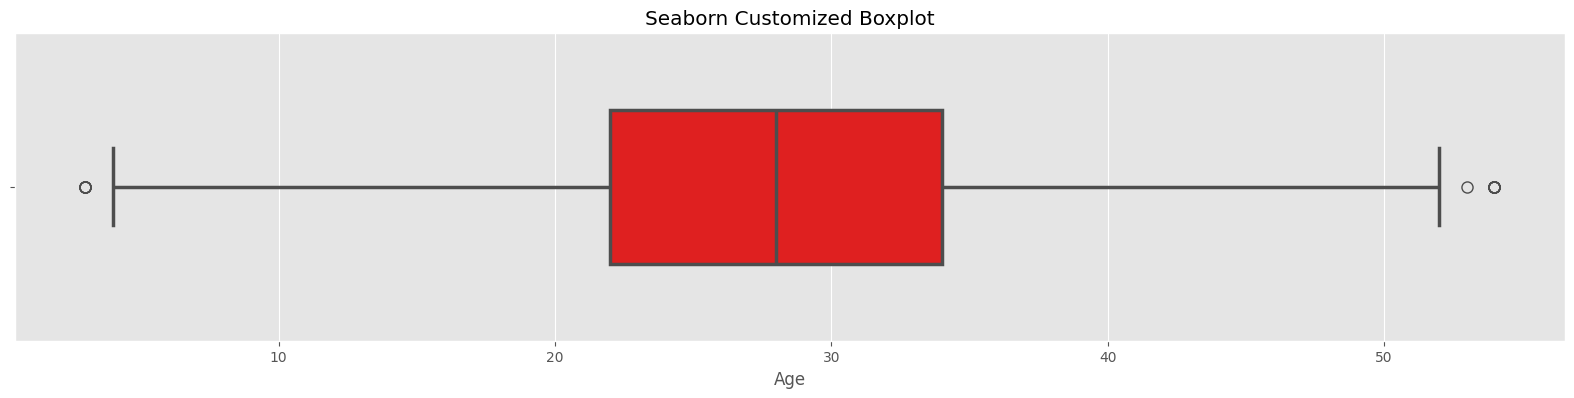

In [177]:
# Outlier Detection for 'Age' after remove outlier
plt.style.use('ggplot')
plt.figure(figsize=(20, 4))
sns.boxplot(
    x=df['Age'],
    color='red',       # The fill color of the box
    linewidth=2.5,         # Thickness of all lines (box, whiskers, etc.)
    fliersize=8,           # Size of the outlier points
    width=0.5              # Thickness/height of the box itself
)
plt.title('Seaborn Customized Boxplot')
plt.show()

In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 825 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      825 non-null    int64  
 1   Sex         825 non-null    object 
 2   Age         825 non-null    float64
 3   SibSp       825 non-null    int64  
 4   Parch       825 non-null    int64  
 5   Fare        825 non-null    float64
 6   Embarked    825 non-null    object 
 7   y           825 non-null    int64  
 8   Title       825 non-null    object 
 9   familySize  825 non-null    int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 70.9+ KB


# 5. Encoding Categorical Data

In [179]:
categorical_cols = ['Sex','Embarked','Title']
df = df.copy()  # ensure no view issues
for col in categorical_cols:
    le = LabelEncoder()
    df.loc[:, col] = le.fit_transform(df[col])

In [180]:
df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,y,Title,familySize
0,3,1,22.0,1,0,7.2500,2,0,9,1
1,1,0,38.0,1,0,71.2833,0,1,10,1
2,3,0,26.0,0,0,7.9250,2,1,6,0
3,1,0,35.0,1,0,53.1000,2,1,10,1
4,3,1,35.0,0,0,8.0500,2,0,9,0
...,...,...,...,...,...,...,...,...,...,...
886,2,1,27.0,0,0,13.0000,2,0,12,0
887,1,0,19.0,0,0,30.0000,2,1,6,0
888,3,0,28.0,1,2,23.4500,2,0,6,3
889,1,1,26.0,0,0,30.0000,0,1,9,0


# 6. Train - Test Split

In [181]:
X = df.drop(['y'], axis=1)
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Scaling

In [182]:
# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 8. Fix Imbalanced Data (SMOTE)

In [183]:
# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:\n", y_train.value_counts(normalize=True))

After SMOTE:
 y
0    0.5
1    0.5
Name: proportion, dtype: float64


##                                               50% ` NO ` , 50% ` YES `


# 9. Training KNN

In [184]:
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8424242424242424


In [185]:
import numpy as np

error_rates = []

for k in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    error = np.mean(y_pred != y_test)
    error_rates.append(error)

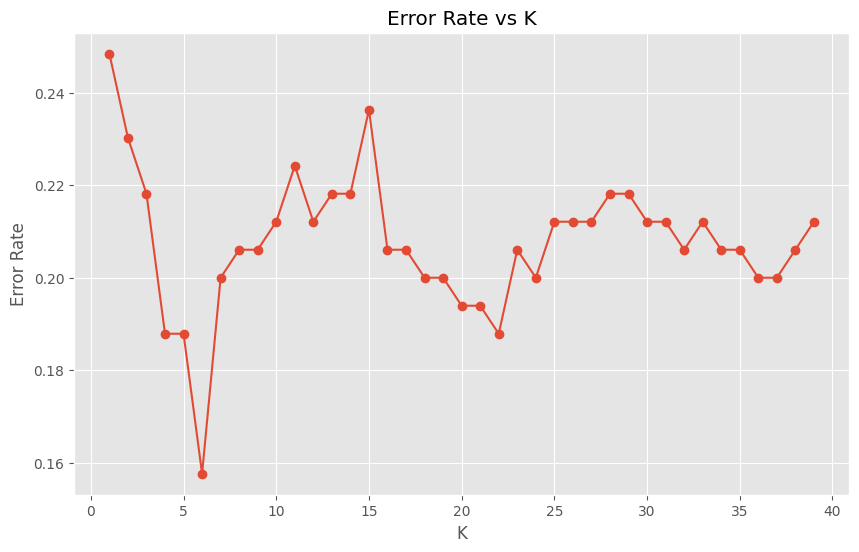

In [186]:
plt.figure(figsize=(10,6))
plt.plot(range(1,40), error_rates, marker='o')
plt.title("Error Rate vs K")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.show()

In [187]:
best_k = error_rates.index(min(error_rates)) + 1
print("Best K:", best_k)

Best K: 6


# 10. KNN Evaluation

In [188]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.78      0.81        99
           1       0.71      0.80      0.75        66

    accuracy                           0.79       165
   macro avg       0.78      0.79      0.78       165
weighted avg       0.80      0.79      0.79       165



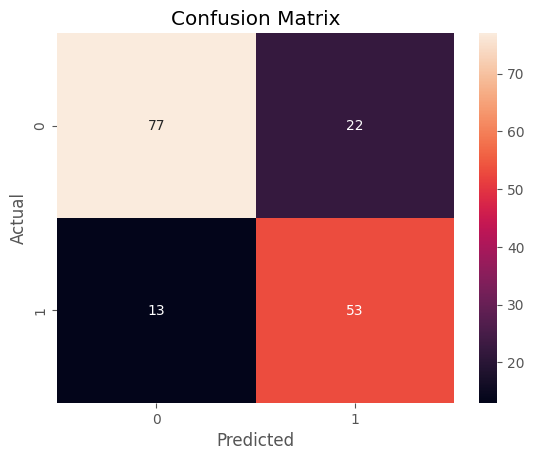

In [190]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 11. Decision Tree Model

In [191]:
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

[Text(0.5, 0.875, 'x[1] <= 0.45\ngini = 0.5\nsamples = 824\nvalue = [412, 412]'),
 Text(0.25, 0.625, 'x[0] <= 0.767\ngini = 0.291\nsamples = 339\nvalue = [60, 279]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[5] <= -0.179\ngini = 0.048\nsamples = 202\nvalue = [5, 197]'),
 Text(0.0625, 0.125, 'gini = 0.124\nsamples = 45\nvalue = [3, 42]'),
 Text(0.1875, 0.125, 'gini = 0.025\nsamples = 157\nvalue = [2, 155]'),
 Text(0.375, 0.375, 'x[5] <= -0.152\ngini = 0.481\nsamples = 137\nvalue = [55, 82]'),
 Text(0.3125, 0.125, 'gini = 0.432\nsamples = 117\nvalue = [37, 80]'),
 Text(0.4375, 0.125, 'gini = 0.18\nsamples = 20\nvalue = [18, 2]'),
 Text(0.75, 0.625, 'x[0] <= -0.578\ngini = 0.398\nsamples = 485\nvalue = [352, 133]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[5] <= -0.391\ngini = 0.498\nsamples = 101\nvalue = [47, 54]'),
 Text(0.5625, 0.125, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.6875, 0.125, 'gini = 0.492\nsamples = 96\nvalue = [42, 54]'),
 Text(0.875, 

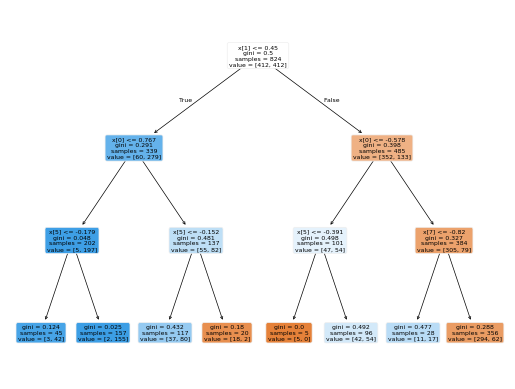

In [192]:
from sklearn.tree import plot_tree
plot_tree(clf,filled=True,rounded=True)

In [193]:
y_pred = clf.predict(X_test)

In [194]:
print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with criterion gini index: 0.7879


In [195]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.73      0.80        99
           1       0.68      0.88      0.77        66

    accuracy                           0.79       165
   macro avg       0.79      0.80      0.79       165
weighted avg       0.81      0.79      0.79       165



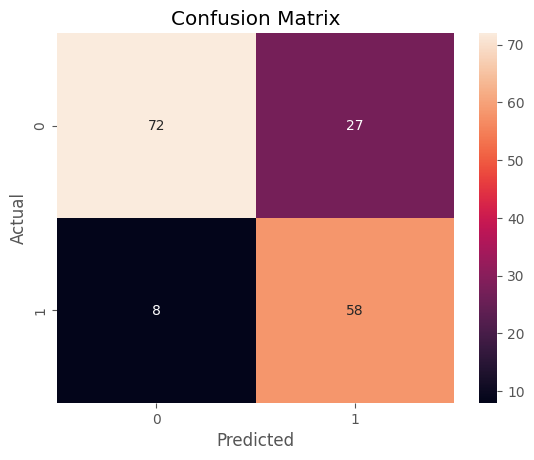

In [196]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()